In [2]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [7]:
import os

os.chdir(r"C:\Users\shree\Downloads\Customer 360 Intelligence Platform – E-Commerce Analytics")

os.getcwd()

'C:\\Users\\shree\\Downloads\\Customer 360 Intelligence Platform – E-Commerce Analytics'

In [9]:
import pandas as pd

customers = pd.read_csv("Data/olist_customers_dataset.csv")

orders = pd.read_csv("Data/olist_orders_dataset.csv")

items = pd.read_csv("Data/olist_order_items_dataset.csv")

payments = pd.read_csv("Data/olist_order_payments_dataset.csv")

reviews = pd.read_csv("Data/olist_order_reviews_dataset.csv")

products = pd.read_csv("Data/olist_products_dataset.csv")

sellers = pd.read_csv("Data/olist_sellers_dataset.csv")

geolocation = pd.read_csv("Data/olist_geolocation_dataset.csv")

translation = pd.read_csv("Data/product_category_name_translation.csv")

In [10]:
print("Customers:", customers.shape)
print("Orders:", orders.shape)
print("Items:", items.shape)
print("Payments:", payments.shape)
print("Reviews:", reviews.shape)
print("Products:", products.shape)

Customers: (99441, 5)
Orders: (99441, 8)
Items: (112650, 7)
Payments: (103886, 5)
Reviews: (99224, 7)
Products: (32951, 9)


# Data Understanding

In this step, multiple e-commerce datasets were analyzed to understand:

- Dataset size
- Available features
- Data types
- Numerical statistics
- Relationships between tables

In [14]:
customers.info()

orders.info()

items.info()

payments.info()

reviews.info()

products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4

In [13]:
print(customers.columns)

print(orders.columns)

print(items.columns)

print(payments.columns)

print(reviews.columns)

print(products.columns)

Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='object')
Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='object')
Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='object')
Index(['order_id', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value'],
      dtype='object')
Index(['review_id', 'order_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp'],
      dtype='object')
Index(['product_id', 'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm

# Data Cleaning

Tasks performed:
- Missing value detection
- Duplicate checking
- Datatype conversion
- Feature engineering

In [15]:
datasets = {
    "Customers": customers,
    "Orders": orders,
    "Items": items,
    "Payments": payments,
    "Reviews": reviews,
    "Products": products
}


for name,data in datasets.items():
    print("\n",name)
    print(data.isnull().sum())



 Customers
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

 Orders
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

 Items
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

 Payments
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

 Reviews
review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_

In [16]:
# ==============================
# 2. Clean Orders Dataset
# ==============================

# Keep only delivered orders for delivery analysis

delivered_orders = orders[
    orders['order_status'] == 'delivered'
]

print("\nDelivered Orders Shape:")
print(delivered_orders.shape)



# ==============================
# 3. Clean Reviews Dataset
# ==============================

# Replace missing review comments

reviews['review_comment_message'] = (
    reviews['review_comment_message']
    .fillna("No Review")
)


# Replace missing review titles

reviews['review_comment_title'] = (
    reviews['review_comment_title']
    .fillna("No Title")
)



# ==============================
# 4. Clean Products Dataset
# ==============================

# Missing category replaced as unknown

products['product_category_name'] = (
    products['product_category_name']
    .fillna("unknown")
)


# Numerical missing values replaced with 0

products[
[
'product_name_lenght',
'product_description_lenght',
'product_photos_qty',
'product_weight_g',
'product_length_cm',
'product_height_cm',
'product_width_cm'
]
] = products[
[
'product_name_lenght',
'product_description_lenght',
'product_photos_qty',
'product_weight_g',
'product_length_cm',
'product_height_cm',
'product_width_cm'
]
].fillna(0)



# ==============================
# 5. Check Missing Values After Cleaning
# ==============================


datasets_cleaned = {
    "Customers": customers,
    "Orders": delivered_orders,
    "Items": items,
    "Payments": payments,
    "Reviews": reviews,
    "Products": products
}


print("\n\nMissing Values After Cleaning")


for name,data in datasets_cleaned.items():
    print("\n",name)
    print(data.isnull().sum())



Delivered Orders Shape:
(96478, 8)


Missing Values After Cleaning

 Customers
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

 Orders
order_id                          0
customer_id                       0
order_status                      0
order_purchase_timestamp          0
order_approved_at                14
order_delivered_carrier_date      2
order_delivered_customer_date     8
order_estimated_delivery_date     0
dtype: int64

 Items
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

 Payments
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

 Reviews
review_id                  0
order_id                   0
review_score               0


In [17]:
# Remove remaining missing date records

delivered_orders = delivered_orders.dropna()


# Verify again

delivered_orders.isnull().sum()

order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
dtype: int64

In [18]:
# Duplicate checking

for name,data in datasets_cleaned.items():
    print(name,":",data.duplicated().sum())

Customers : 0
Orders : 0
Items : 0
Payments : 0
Reviews : 0
Products : 0


#Feature Engineering

In [19]:
# Convert date columns

date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]


for col in date_columns:
    delivered_orders[col] = pd.to_datetime(delivered_orders[col])


In [20]:
delivered_orders.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96455 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96455 non-null  object        
 1   customer_id                    96455 non-null  object        
 2   order_status                   96455 non-null  object        
 3   order_purchase_timestamp       96455 non-null  datetime64[ns]
 4   order_approved_at              96455 non-null  datetime64[ns]
 5   order_delivered_carrier_date   96455 non-null  datetime64[ns]
 6   order_delivered_customer_date  96455 non-null  datetime64[ns]
 7   order_estimated_delivery_date  96455 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.6+ MB


In [21]:
# Calculate delivery duration

delivered_orders['delivery_days'] = (
    delivered_orders['order_delivered_customer_date']
    -
    delivered_orders['order_purchase_timestamp']
).dt.days

In [22]:
delivered_orders[
[
'order_purchase_timestamp',
'order_delivered_customer_date',
'delivery_days'
]
].head(10)

,order_purchase_timestamp,order_delivered_customer_date,delivery_days
0,2017-10-02 10:56:33,2017-10-10 21:25:13,8
1,2018-07-24 20:41:37,2018-08-07 15:27:45,13
2,2018-08-08 08:38:49,2018-08-17 18:06:29,9
3,2017-11-18 19:28:06,2017-12-02 00:28:42,13
4,2018-02-13 21:18:39,2018-02-16 18:17:02,2
5,2017-07-09 21:57:05,2017-07-26 10:57:55,16
7,2017-05-16 13:10:30,2017-05-26 12:55:51,9
8,2017-01-23 18:29:09,2017-02-02 14:08:10,9
9,2017-07-29 11:55:02,2017-08-16 17:14:30,18
10,2017-05-16 19:41:10,2017-05-29 11:18:31,12


In [23]:
# Extract purchase month

delivered_orders['purchase_month'] = (
    delivered_orders['order_purchase_timestamp']
    .dt.month
)

In [24]:
delivered_orders['purchase_year'] = (
    delivered_orders['order_purchase_timestamp']
    .dt.year
)

In [25]:
delivered_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,purchase_month,purchase_year
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8,10,2017
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13,7,2018
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9,8,2018
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13,11,2017
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2,2,2018


In [26]:
# Create revenue feature

items['total_revenue'] = (
    items['price'] +
    items['freight_value']
)


items[
[
'price',
'freight_value',
'total_revenue'
]
].head()

,price,freight_value,total_revenue
0,58.90,13.29,72.19
1,239.90,19.93,259.83
2,199.00,17.87,216.87
3,12.99,12.79,25.78
4,199.90,18.14,218.04


In [27]:
customer_orders = delivered_orders.merge(
    customers,
    on='customer_id',
    how='left'
)

customer_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,purchase_month,purchase_year,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8,10,2017,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13,7,2018,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9,8,2018,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13,11,2017,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2,2,2018,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


In [28]:
customer_orders.shape

(96455, 15)

In [29]:
customer_360 = customer_orders.merge(
    items,
    on='order_id',
    how='left'
)

customer_360.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,purchase_month,...,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,total_revenue
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8,10,...,3149,sao paulo,SP,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13,7,...,47813,barreiras,BA,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9,8,...,75265,vianopolis,GO,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13,11,...,59296,sao goncalo do amarante,RN,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2,2,...,9195,santo andre,SP,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,28.62


In [30]:
customer_360.shape

(110173, 22)

In [31]:
customer_360[['customer_unique_id',
              'total_revenue']].head()

,customer_unique_id,total_revenue
0,7c396fd4830fd04220f754e42b4e5bff,38.71
1,af07308b275d755c9edb36a90c618231,141.46
2,3a653a41f6f9fc3d2a113cf8398680e8,179.12
3,7c142cf63193a1473d2e66489a9ae977,72.20
4,72632f0f9dd73dfee390c9b22eb56dd6,28.62


In [32]:
customer_lifetime_value = (
    customer_360
    .groupby('customer_unique_id')['total_revenue']
    .sum()
    .reset_index()
)


customer_lifetime_value.head()

,customer_unique_id,total_revenue
0,0000366f3b9a7992bf8c76cfdf3221e2,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,27.19
2,0000f46a3911fa3c0805444483337064,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,43.62
4,0004aac84e0df4da2b147fca70cf8255,196.89


In [33]:
customer_lifetime_value.rename(
    columns={
        'total_revenue':'customer_lifetime_value'
    },
    inplace=True
)


customer_lifetime_value.head()

,customer_unique_id,customer_lifetime_value
0,0000366f3b9a7992bf8c76cfdf3221e2,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,27.19
2,0000f46a3911fa3c0805444483337064,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,43.62
4,0004aac84e0df4da2b147fca70cf8255,196.89


In [34]:
customer_lifetime_value.sort_values(
    by='customer_lifetime_value',
    ascending=False
).head(10)

,customer_unique_id,customer_lifetime_value
3724,0a0a92112bd4c708ca5fde585afaa872,13664.08
79617,da122df9eeddfedc1dc1f5349a1a690c,7571.63
43161,763c8b1c9c68a0229c42c9fc6f662b93,7274.88
80444,dc4802a71eae9be1dd28f5d788ceb526,6929.31
25431,459bef486812aa25204be022145caa62,6922.21
93059,ff4159b92c40ebe40454e3e6a7c35ed6,6726.66
23406,4007669dec559734d6f53e029e360987,6081.54
87127,eebb5dda148d3893cdaf5b5ca3040ccb,4764.34
26635,48e1ac109decbb87765a3eade6854098,4681.78
73112,c8460e4251689ba205045f3ea17884a1,4655.88


In [35]:
# Average Order Value calculation

average_order_value = (
    customer_360
    .groupby('customer_unique_id')
    .agg(
        total_spent=('total_revenue','sum'),
        total_orders=('order_id','nunique')
    )
    .reset_index()
)


average_order_value['average_order_value'] = (
    average_order_value['total_spent']
    /
    average_order_value['total_orders']
)


average_order_value.head()

,customer_unique_id,total_spent,total_orders,average_order_value
0,0000366f3b9a7992bf8c76cfdf3221e2,141.90,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,27.19,1,27.19
2,0000f46a3911fa3c0805444483337064,86.22,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,43.62,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,196.89,1,196.89


In [36]:
# Create repeat customer flag

average_order_value['customer_type'] = (
    average_order_value['total_orders']
    .apply(lambda x: 'Repeat Customer' if x > 1 else 'One Time Customer')
)


average_order_value.head()

,customer_unique_id,total_spent,total_orders,average_order_value,customer_type
0,0000366f3b9a7992bf8c76cfdf3221e2,141.90,1,141.90,One Time Customer
1,0000b849f77a49e4a4ce2b2a4ca5be3f,27.19,1,27.19,One Time Customer
2,0000f46a3911fa3c0805444483337064,86.22,1,86.22,One Time Customer
3,0000f6ccb0745a6a4b88665a16c9f078,43.62,1,43.62,One Time Customer
4,0004aac84e0df4da2b147fca70cf8255,196.89,1,196.89,One Time Customer


In [37]:
average_order_value.head()

average_order_value['customer_type'].value_counts()

customer_type
One Time Customer    90536
Repeat Customer       2800
Name: count, dtype: int64

In [38]:
# Reference date (latest date + 1)

reference_date = (
    customer_360['order_purchase_timestamp'].max()
    + pd.Timedelta(days=1)
)


rfm = customer_360.groupby(
    'customer_unique_id'
).agg(

    Recency=(
        'order_purchase_timestamp',
        lambda x:(reference_date - x.max()).days
    ),

    Frequency=(
        'order_id',
        'nunique'
    ),

    Monetary=(
        'total_revenue',
        'sum'
    )

).reset_index()


rfm.head()

,customer_unique_id,Recency,Frequency,Monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19
2,0000f46a3911fa3c0805444483337064,537,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89


In [39]:
rfm_features = rfm[
    [
        'Recency',
        'Frequency',
        'Monetary'
    ]
]


rfm_features.head()

,Recency,Frequency,Monetary
0,112,1,141.90
1,115,1,27.19
2,537,1,86.22
3,321,1,43.62
4,288,1,196.89


In [40]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()


rfm_scaled = scaler.fit_transform(
    rfm_features
)


rfm_scaled[:5]

array([[-0.82531682, -0.15981575, -0.1028197 ],
       [-0.80565141, -0.15981575, -0.60968601],
       [ 1.96061578, -0.15981575, -0.34885158],
       [ 0.54470651, -0.15981575, -0.53708717],
       [ 0.32838703, -0.15981575,  0.14016328]])

In [41]:
from sklearn.cluster import KMeans


kmeans = KMeans(
    n_clusters=3,
    random_state=42
)


rfm['Cluster'] = kmeans.fit_predict(
    rfm_scaled
)


rfm.head()

,customer_unique_id,Recency,Frequency,Monetary,Cluster
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,2
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,2
2,0000f46a3911fa3c0805444483337064,537,1,86.22,0
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,0
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89,0


In [42]:
cluster_analysis = rfm.groupby(
    'Cluster'
).agg(
    {
        'Recency':'mean',
        'Frequency':'mean',
        'Monetary':'mean',
        'customer_unique_id':'count'
    }
)


cluster_analysis

,Recency,Frequency,Monetary,customer_unique_id
Cluster,,,,
0,387.682835,1.000000,161.207192,38428
1,220.405916,2.111547,324.834857,2806
2,128.376243,1.000000,159.492720,52102


In [43]:
# Mapping clusters to customer segments

cluster_labels = {
    0 : "At Risk Customer",
    1 : "Premium Customer",
    2 : "Regular Customer"
}


rfm['Customer_Segment'] = (
    rfm['Cluster']
    .map(cluster_labels)
)


rfm.head()

,customer_unique_id,Recency,Frequency,Monetary,Cluster,Customer_Segment
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,2,Regular Customer
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,2,Regular Customer
2,0000f46a3911fa3c0805444483337064,537,1,86.22,0,At Risk Customer
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,0,At Risk Customer
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89,0,At Risk Customer


In [44]:
rfm['Customer_Segment'].value_counts()

Customer_Segment
Regular Customer    52102
At Risk Customer    38428
Premium Customer     2806
Name: count, dtype: int64

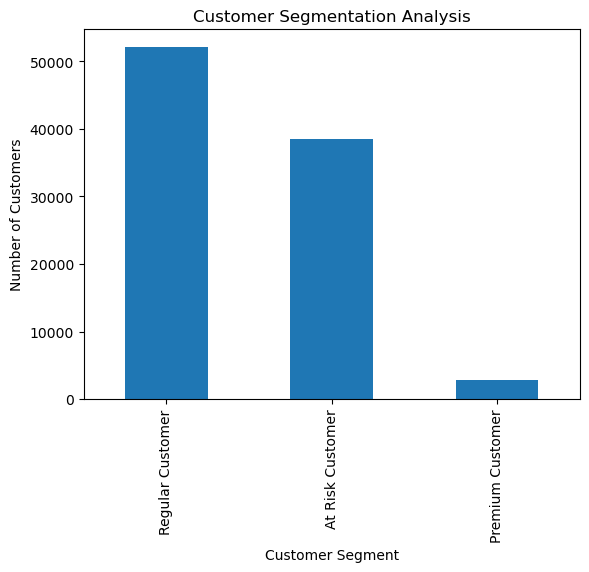

In [45]:
import matplotlib.pyplot as plt


rfm['Customer_Segment'].value_counts().plot(
    kind='bar'
)


plt.title("Customer Segmentation Analysis")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.show()

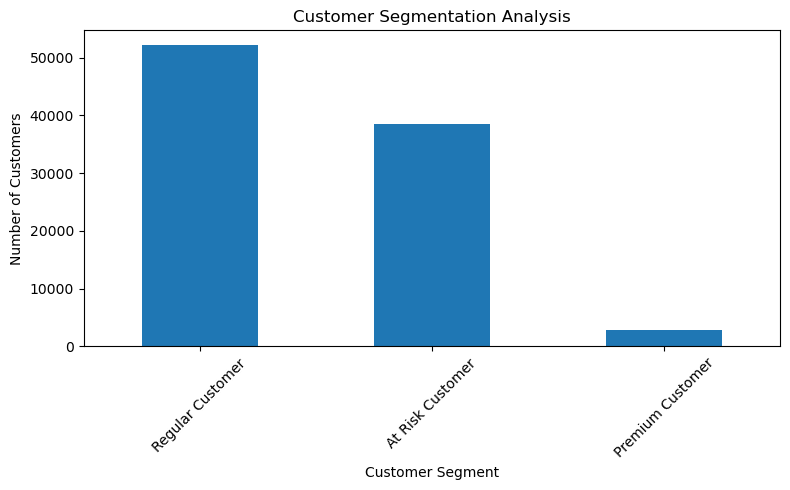

In [46]:
import matplotlib.pyplot as plt


rfm['Customer_Segment'].value_counts().plot(
    kind='bar',
    figsize=(8,5)
)


plt.title("Customer Segmentation Analysis")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")


plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [48]:
import os

os.chdir(
    r"C:\Users\shree\Downloads\Customer 360 Intelligence Platform – E-Commerce Analytics"
)

os.getcwd()

'C:\\Users\\shree\\Downloads\\Customer 360 Intelligence Platform – E-Commerce Analytics'

In [50]:
rfm.to_csv(
    "Data/customer_segments.csv",
    index=False
)

In [51]:
import os

os.listdir("Data")

['customer_segments.csv',
 'olist_customers_dataset.csv',
 'olist_geolocation_dataset.csv',
 'olist_orders_dataset.csv',
 'olist_order_items_dataset.csv',
 'olist_order_payments_dataset.csv',
 'olist_order_reviews_dataset.csv',
 'olist_products_dataset.csv',
 'olist_sellers_dataset.csv',
 'product_category_name_translation.csv']

In [52]:
reviews[
[
'review_score',
'review_comment_message'
]
].head(10)

,review_score,review_comment_message
0,4,No Review
1,5,No Review
2,5,No Review
3,5,Recebi bem antes do prazo estipulado.
4,5,Parabéns lojas lannister adorei comprar pela I...
5,1,No Review
6,5,No Review
7,5,No Review
8,5,No Review
9,4,aparelho eficiente. no site a marca do aparelh...


In [53]:
sentiment_data = reviews[
    reviews['review_comment_message'] != "No Review"
]


sentiment_data.shape

(40977, 7)

In [56]:
!pip install textblob
from textblob import TextBlob
TextBlob(
    "Product is good and delivery was fast"
).sentiment

Defaulting to user installation because normal site-packages is not writeable


Sentiment(polarity=0.44999999999999996, subjectivity=0.6000000000000001)

In [63]:
def get_sentiment(text):

    score = TextBlob(text).sentiment.polarity

    if score > 0:
        return "Positive"

    elif score < 0:
        return "Negative"

    else:
        return "Neutral"

In [64]:
sentiment_data['Sentiment'] = (
    sentiment_data['review_comment_message']
    .apply(get_sentiment)
)


sentiment_data.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,Sentiment
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,No Title,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06,Neutral
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,No Title,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53,Neutral
9,8670d52e15e00043ae7de4c01cc2fe06,b9bf720beb4ab3728760088589c62129,4,recomendo,aparelho eficiente. no site a marca do aparelh...,2018-05-22 00:00:00,2018-05-23 16:45:47,Neutral
12,4b49719c8a200003f700d3d986ea1a19,9d6f15f95d01e79bd1349cc208361f09,4,No Title,"Mas um pouco ,travando...pelo valor ta Boa.\r\n",2018-02-16 00:00:00,2018-02-20 10:52:22,Neutral
15,3948b09f7c818e2d86c9a546758b2335,e51478e7e277a83743b6f9991dbfa3fb,5,Super recomendo,"Vendedor confiável, produto ok e entrega antes...",2018-05-23 00:00:00,2018-05-24 03:00:01,Positive


In [65]:
sentiment_data['Sentiment'].value_counts()

Sentiment
Neutral     37474
Positive     3047
Negative      456
Name: count, dtype: int64

In [67]:
def sentiment_from_score(score):

    if score >= 4:
        return "Positive"

    elif score == 3:
        return "Neutral"

    else:
        return "Negative"


sentiment_data['Sentiment'] = (
    sentiment_data['review_score']
    .apply(sentiment_from_score)
)


sentiment_data['Sentiment'].value_counts()

Sentiment
Positive    26530
Negative    10890
Neutral      3557
Name: count, dtype: int64

In [70]:
sentiment_data.to_csv(
    "Data/customer_sentiment.csv",
    index=False
)

In [71]:
customer_360.to_csv(
    "Data/customer_360_master.csv",
    index=False
)
